- Segment main objects/regions from image
 
  Can use:
  - Thresholding
  - Region Growing
  - Watershed
  - K-means segmentation

### Goal: Isolate the region of interest (tumor / meaningful brain region) from the MRI

In [1]:
from pathlib import Path
import sys

# BASE_DIR = Path(__file__).resolve().parent
BASE_DIR = Path().resolve().parent

sys.path.append(str(BASE_DIR))

train_path = BASE_DIR / "data" / "raw" / "Training"
test_path = BASE_DIR / "data" / "raw" / "Testing"

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from modules.data_loader import load_data
from modules.preprocessing import standardize

X_train, y_train = load_data(train_path)
X_test, y_test = load_data(test_path)

# Apply preprocessing to the loaded data
X_train = [standardize(img) for img in X_train]
X_test = [standardize(img) for img in X_test]

In [3]:
from modules.segmentation import threshold_segmentation, kmeans_segmentation, get_threshold_mask, get_kmeans_mask, compute_iou

img = X_train[0]

# automatically finds optimal threshold andsplits image into:
# foreground (bright regions) , background (dark regions)
thresh = threshold_segmentation(img)

# groups pixels based on intensity into k regions (k distinct intensity levels)
kmeans = kmeans_segmentation(img, k=3)

In [4]:
img = X_test[0]

th_mask = get_threshold_mask(img)
km_mask = get_kmeans_mask(kmeans_segmentation(img))

iou_score = compute_iou(th_mask, km_mask)

print("IoU (Threshold vs KMeans):", iou_score)

IoU (Threshold vs KMeans): 0.9832523493574723


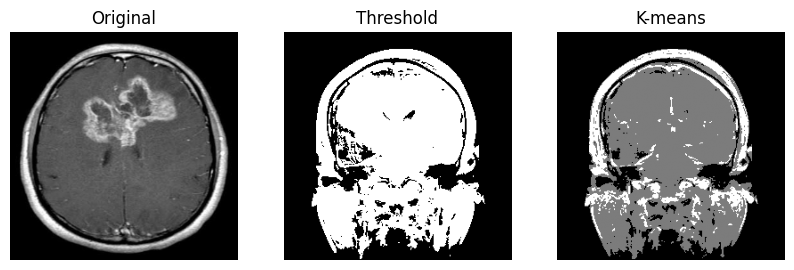

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(thresh, cmap="gray")
plt.title("Threshold")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(kmeans, cmap="gray")
plt.title("K-means")
plt.axis("off")

plt.show()

K-means segmentation produced more informative and structured region separation compared to Otsu thresholding. This is likely due to its ability to cluster pixels into multiple intensity-based groups, which better captures the heterogeneous nature of MRI brain images.